# LINE -> PAGE

Device: mps


Processing VAL pages: 100%|██████████| 27/27 [00:18<00:00,  1.45it/s]



PAGE ACCURACY (LINES → PAGE → AUTHOR): 77.78%


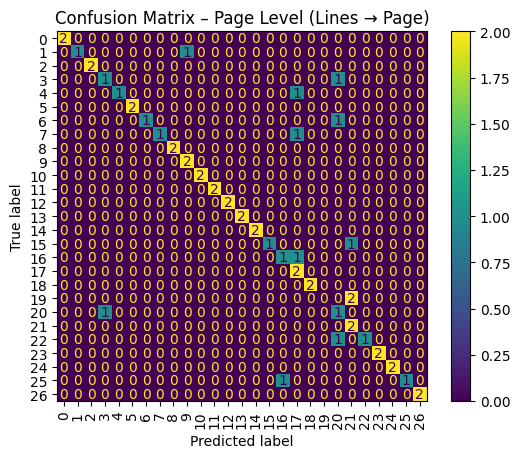

In [ ]:
# LINIA STRONA AUTOR (EWALUACJA WALIDACYJNA)
import os
import json
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# KONFIGURACJA
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

PAGES_DIR = "/Users/maciekgrubek/Downloads/cvl-database-1-1/trainset/pages"
MODEL_LINES_PATH = "/Users/maciekgrubek/PracaInzynierska/best_model_lines.pth"
AUTHORS_JSON = "/Users/maciekgrubek/PracaInzynierska/authors.json"
SPLIT_PAGES_JSON = "/Users/maciekgrubek/PracaInzynierska/split_pages_lines_27.json"

# MAPOWANIE AUTORÓW

with open(AUTHORS_JSON, "r") as f:
    author_to_label = json.load(f)

num_authors = len(author_to_label)

# WCZYTANIE PODZIAŁU STRON (TYLKO WALIDACJA)

with open(SPLIT_PAGES_JSON, "r") as f:
    split_pages = json.load(f)

# MODEL LINII

model_lines = models.resnet50(weights=None)
model_lines.fc = nn.Sequential(
    nn.Linear(model_lines.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_authors)
)

model_lines.load_state_dict(
    torch.load(MODEL_LINES_PATH, map_location=device)
)
model_lines.to(device)
model_lines.eval()

# TRANSFORMACJE LINII

transform_line = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# SEGMENTACJA LINII (SPRAWDZONA)

HEADER_CUT = {
    1: 820, 2: 900, 3: 820, 4: 720,
    6: 930, 7: 770, 8: 770
}

def extract_lines_projection(page_img,
                             min_line_height=45,
                             proj_percentile=70):

    blur = cv2.GaussianBlur(page_img, (5, 5), 0)

    th = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51, 9
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (35, 3))
    th = cv2.dilate(th, kernel, iterations=1)

    proj = np.sum(th > 0, axis=1)
    thresh_val = np.percentile(proj, proj_percentile)

    lines = []
    in_line = False
    start_y = 0

    for y, val in enumerate(proj):
        if not in_line and val > thresh_val:
            in_line = True
            start_y = y
        elif in_line and val <= thresh_val:
            end_y = y
            if end_y - start_y >= min_line_height:
                lines.append((0, start_y,
                              page_img.shape[1],
                              end_y - start_y))
            in_line = False

    if in_line:
        end_y = len(proj) - 1
        if end_y - start_y >= min_line_height:
            lines.append((0, start_y,
                          page_img.shape[1],
                          end_y - start_y))

    return lines

# PREDYKCJA AUTORA STRONY

def predict_page_author(page_path):

    img = cv2.imread(page_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    base = os.path.basename(page_path)
    page_num = int(base.split("-")[1].split(".")[0])
    cut_y = HEADER_CUT.get(page_num, 700)

    img_cropped = img[cut_y:, :]

    lines = extract_lines_projection(img_cropped)
    if len(lines) == 0:
        return None

    preds = []

    for x, y, w, h in lines:
        crop = img_cropped[y:y+h, x:x+w]
        tensor = transform_line(crop).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model_lines(tensor)
            pred = out.argmax(1).item()
            preds.append(pred)

    return Counter(preds).most_common(1)[0][0]

# EWALUACJA – TYLKO STRONY WALIDACYJNE

page_labels = []
page_preds = []

for author_id, info in tqdm(split_pages.items(),
                            desc="Processing VAL pages"):

    for page_id in info["val_pages"]:
        page_name = f"{author_id}-{page_id}.tif"
        page_path = os.path.join(PAGES_DIR, page_name)

        if not os.path.exists(page_path):
            continue

        pred = predict_page_author(page_path)
        if pred is None:
            continue

        true_label = author_to_label[author_id]

        page_labels.append(true_label)
        page_preds.append(pred)

page_labels = np.array(page_labels)
page_preds = np.array(page_preds)

# WYNIKI

assert len(page_labels) > 0, "Brak poprawnych predykcji!"

acc = np.mean(page_labels == page_preds)
print(f"\nPAGE ACCURACY (LINES → PAGE → AUTHOR): {acc*100:.2f}%")

cm = confusion_matrix(page_labels, page_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix – Page Level (Lines → Page)")
plt.show()


# Sprawdzanie wycinania linii


Wykryto linii: 9


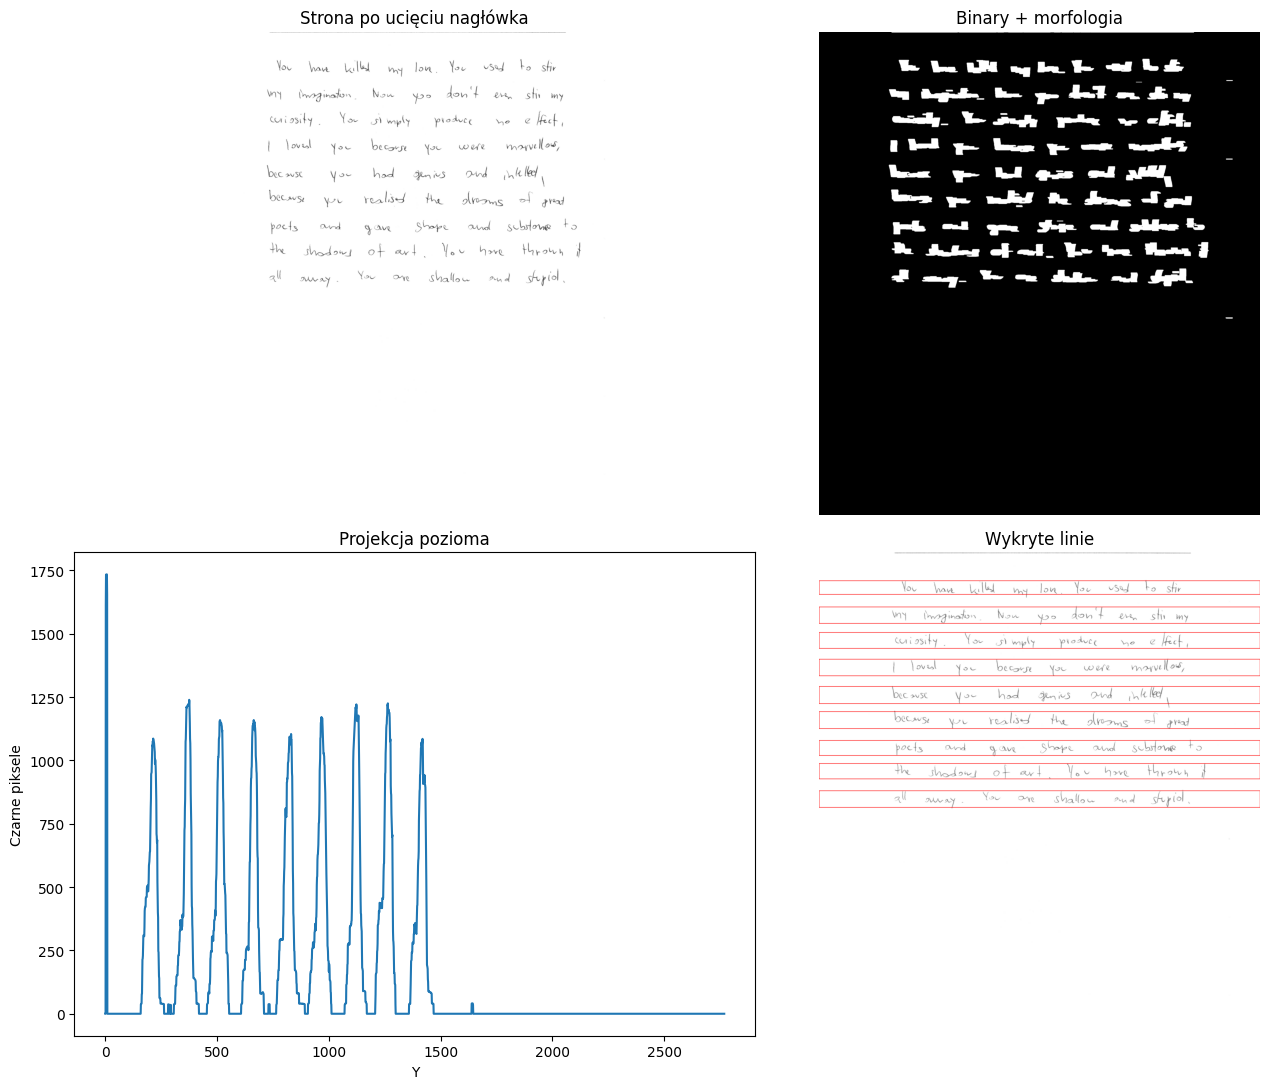

Zapisano linie do: debug_lines


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# KONFIGURACJA 

PAGE_PATH = "/Users/maciekgrubek/Downloads/cvl-database-1-1/trainset/pages/0001-7.tif"
SAVE_LINES = True  # Jeśli chcesz zapisać wykryte linie jako obrazy
SAVE_DIR = "debug_lines"

HEADER_CUT = {
    1: 820, 2: 900, 3: 820, 4: 720,
    6: 930, 7: 770, 8: 770
}

# FUNKCJA EKSTRAKCJI LINII

def extract_lines_debug(page_img,
                        min_line_height=45,
                        proj_percentile=70):

    blur = cv2.GaussianBlur(page_img, (5, 5), 0)

    th = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51, 9
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (35, 3))
    th_morph = cv2.dilate(th, kernel, iterations=1)

    proj = np.sum(th_morph > 0, axis=1)
    thresh_val = np.percentile(proj, proj_percentile)

    lines = []
    in_line = False
    start_y = 0

    for y, val in enumerate(proj):
        if not in_line and val > thresh_val:
            in_line = True
            start_y = y
        elif in_line and val <= thresh_val:
            end_y = y
            if end_y - start_y >= min_line_height:
                lines.append((0, start_y, page_img.shape[1], end_y - start_y))
            in_line = False

    if in_line:
        end_y = len(proj) - 1
        if end_y - start_y >= min_line_height:
            lines.append((0, start_y, page_img.shape[1], end_y - start_y))

    return lines, th_morph, proj


# DEBUGGER

def debug_page(page_path):

    img = cv2.imread(page_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Błąd: nie mogę wczytać strony.")
        return

    base = os.path.basename(page_path)
    page_id = int(base.split("-")[1].split(".")[0])

    cut_y = HEADER_CUT.get(page_id, 700)

    img_cut = img[cut_y:, :]

    lines, th, proj = extract_lines_debug(img_cut)

    print(f"\nWykryto linii: {len(lines)}")

    vis = cv2.cvtColor(img_cut, cv2.COLOR_GRAY2BGR)
    for x, y, w, h in lines:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)

    plt.figure(figsize=(14, 11))

    plt.subplot(2, 2, 1)
    plt.title("Strona po ucięciu nagłówka")
    plt.imshow(img_cut, cmap="gray")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.title("Binary + morfologia")
    plt.imshow(th, cmap="gray")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.title("Projekcja pozioma")
    plt.plot(proj)
    plt.xlabel("Y")
    plt.ylabel("Czarne piksele")

    plt.subplot(2, 2, 4)
    plt.title("Wykryte linie")
    plt.imshow(vis[:, :, ::-1])
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    if SAVE_LINES:
        os.makedirs(SAVE_DIR, exist_ok=True)
        for i, (x, y, w, h) in enumerate(lines):
            crop = img_cut[y:y+h, x:x+w]
            cv2.imwrite(f"{SAVE_DIR}/line_{i}.png", crop)
        print(f"Zapisano linie do: {SAVE_DIR}")


# TEST 

debug_page(PAGE_PATH)
